<a href="https://colab.research.google.com/github/Anhyejaung/hakyeon-research_club/blob/main/week4_seoul_cafe_market_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# 4주차 공개데이터 분석 실습

## 주제: 카페 창업을 위한 서울특별시 구별 상권 분석

서울 열린데이터광장에서 제공하는 서울시 상권분석서비스 데이터를 활용하여
2026년 1분기 기준 서울 25개 자치구의 카페 점포 수를 비교한다.

또한 일반 카페와 프랜차이즈 카페의 점포 수를 함께 비교하여
서울 지역별 카페 경쟁 현황을 기초적으로 분석한다.


In [1]:
import pandas as pd

In [3]:
df = pd.read_csv(
    "/content/서울시 상권분석서비스(점포-자치구).csv",
    encoding="cp949"
)

print("데이터 불러오기 완료")

FileNotFoundError: [Errno 2] No such file or directory: '/content/서울시 상권분석서비스(점포-자치구).csv'

In [6]:
df = pd.read_csv(
    "/content/sample_data/서울시 상권분석서비스(점포-자치구).csv",
    encoding="cp949"
)

print("데이터 불러오기 완료")

데이터 불러오기 완료


In [7]:
df.head()

,기준_년분기_코드,자치구_코드,자치구_코드_명,서비스_업종_코드,서비스_업종_코드_명,전체_점포_수,일반_점포_수,프랜차이즈_점포_수,개업_율,개업_점포_수,폐업_률,폐업_점포_수
0,20261,11740,강동구,CS300043,전자상거래업,779.0,779.0,0.0,0.3,2.0,9.0,70.0
1,20261,11740,강동구,CS300042,주유소,43.0,43.0,0.0,0.0,0.0,4.7,2.0
2,20261,11740,강동구,CS300041,예술품,30.0,30.0,0.0,10.0,3.0,0.0,0.0
3,20261,11740,강동구,CS300040,재생용품 판매점,42.0,42.0,0.0,0.0,0.0,0.0,0.0
4,20261,11740,강동구,CS300039,모터사이클및부품,20.0,20.0,0.0,0.0,0.0,5.0,1.0


In [8]:
print(df.columns)

Index(['기준_년분기_코드', '자치구_코드', '자치구_코드_명', '서비스_업종_코드', '서비스_업종_코드_명',
       '전체_점포_수', '일반_점포_수', '프랜차이즈_점포_수', '개업_율', '개업_점포_수', '폐업_률',
       '폐업_점포_수'],
      dtype='object')


In [9]:
print(df.shape)

(52270, 12)


In [10]:
selected_df = df[
    [
        "기준_년분기_코드",
        "자치구_코드_명",
        "서비스_업종_코드_명",
        "전체_점포_수",
        "일반_점포_수",
        "프랜차이즈_점포_수",
        "개업_율",
        "폐업_률"
    ]
]

selected_df.head()

,기준_년분기_코드,자치구_코드_명,서비스_업종_코드_명,전체_점포_수,일반_점포_수,프랜차이즈_점포_수,개업_율,폐업_률
0,20261,강동구,전자상거래업,779.0,779.0,0.0,0.3,9.0
1,20261,강동구,주유소,43.0,43.0,0.0,0.0,4.7
2,20261,강동구,예술품,30.0,30.0,0.0,10.0,0.0
3,20261,강동구,재생용품 판매점,42.0,42.0,0.0,0.0,0.0
4,20261,강동구,모터사이클및부품,20.0,20.0,0.0,0.0,5.0


In [11]:
print(selected_df.isnull().sum())

기준_년분기_코드      0
자치구_코드_명       0
서비스_업종_코드_명    0
전체_점포_수        0
일반_점포_수        0
프랜차이즈_점포_수     0
개업_율           0
폐업_률           0
dtype: int64


In [12]:
print(
    selected_df[
        selected_df["서비스_업종_코드_명"].str.contains("커피|카페", na=False)
    ]["서비스_업종_코드_명"].unique()
)

['커피-음료']


In [13]:
cafe_df = selected_df[
    selected_df["서비스_업종_코드_명"] == "커피-음료"
]

cafe_df.head()

,기준_년분기_코드,자치구_코드_명,서비스_업종_코드_명,전체_점포_수,일반_점포_수,프랜차이즈_점포_수,개업_율,폐업_률
90,20261,강동구,커피-음료,931.0,679.0,252.0,2.7,3.0
190,20261,송파구,커피-음료,1613.0,1189.0,424.0,3.7,4.5
290,20261,강남구,커피-음료,2561.0,1911.0,650.0,2.7,3.3
390,20261,서초구,커피-음료,1565.0,1192.0,373.0,3.1,3.1
490,20261,관악구,커피-음료,915.0,696.0,219.0,3.6,5.0


In [14]:
print(cafe_df.shape)

(525, 8)


In [15]:
print(sorted(cafe_df["기준_년분기_코드"].unique()))

[np.int64(20211), np.int64(20212), np.int64(20213), np.int64(20214), np.int64(20221), np.int64(20222), np.int64(20223), np.int64(20224), np.int64(20231), np.int64(20232), np.int64(20233), np.int64(20234), np.int64(20241), np.int64(20242), np.int64(20243), np.int64(20244), np.int64(20251), np.int64(20252), np.int64(20253), np.int64(20254), np.int64(20261)]


In [16]:
latest_cafe_df = cafe_df[
    cafe_df["기준_년분기_코드"] == 20261
]

latest_cafe_df.head()

,기준_년분기_코드,자치구_코드_명,서비스_업종_코드_명,전체_점포_수,일반_점포_수,프랜차이즈_점포_수,개업_율,폐업_률
90,20261,강동구,커피-음료,931.0,679.0,252.0,2.7,3.0
190,20261,송파구,커피-음료,1613.0,1189.0,424.0,3.7,4.5
290,20261,강남구,커피-음료,2561.0,1911.0,650.0,2.7,3.3
390,20261,서초구,커피-음료,1565.0,1192.0,373.0,3.1,3.1
490,20261,관악구,커피-음료,915.0,696.0,219.0,3.6,5.0


In [17]:
print(latest_cafe_df.shape)

(25, 8)


In [18]:
sorted_cafe_df = latest_cafe_df.sort_values(
    by="전체_점포_수",
    ascending=False
)

sorted_cafe_df[
    ["자치구_코드_명", "전체_점포_수"]
]

,자치구_코드_명,전체_점포_수
290,강남구,2561.0
1188,마포구,2320.0
190,송파구,1613.0
2485,종로구,1567.0
390,서초구,1565.0
690,영등포구,1421.0
2385,중구,1367.0
989,강서구,1270.0
2285,용산구,1121.0
2185,성동구,1026.0


In [19]:
import matplotlib.pyplot as plt

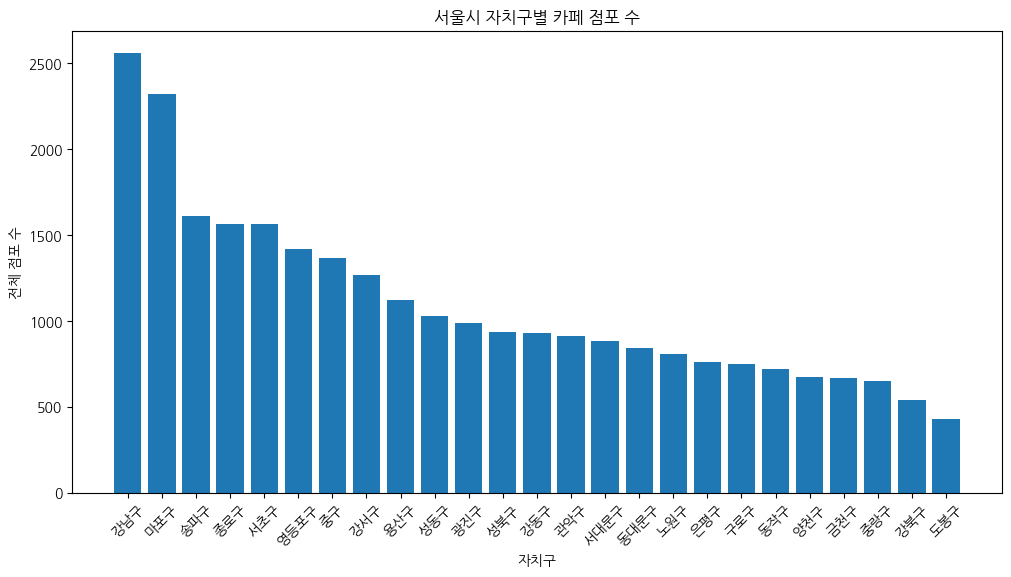

In [25]:
plt.figure(figsize=(12, 6))

plt.bar(
    sorted_cafe_df["자치구_코드_명"],
    sorted_cafe_df["전체_점포_수"]
)

plt.title("서울시 자치구별 카페 점포 수")
plt.xlabel("자치구")
plt.ylabel("전체 점포 수")
plt.xticks(rotation=45)

plt.show()

In [21]:
!apt-get -qq install fonts-nanum

Selecting previously unselected package fonts-nanum.
(Reading database ... 118332 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [24]:
import matplotlib.font_manager as fm

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(font_path)

plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

print("한글 폰트 설정 완료")

한글 폰트 설정 완료


In [26]:
compare_df = sorted_cafe_df[
    ["자치구_코드_명", "일반_점포_수", "프랜차이즈_점포_수"]
]

compare_df.head()

,자치구_코드_명,일반_점포_수,프랜차이즈_점포_수
290,강남구,1911.0,650.0
1188,마포구,1955.0,365.0
190,송파구,1189.0,424.0
2485,종로구,1273.0,294.0
390,서초구,1192.0,373.0


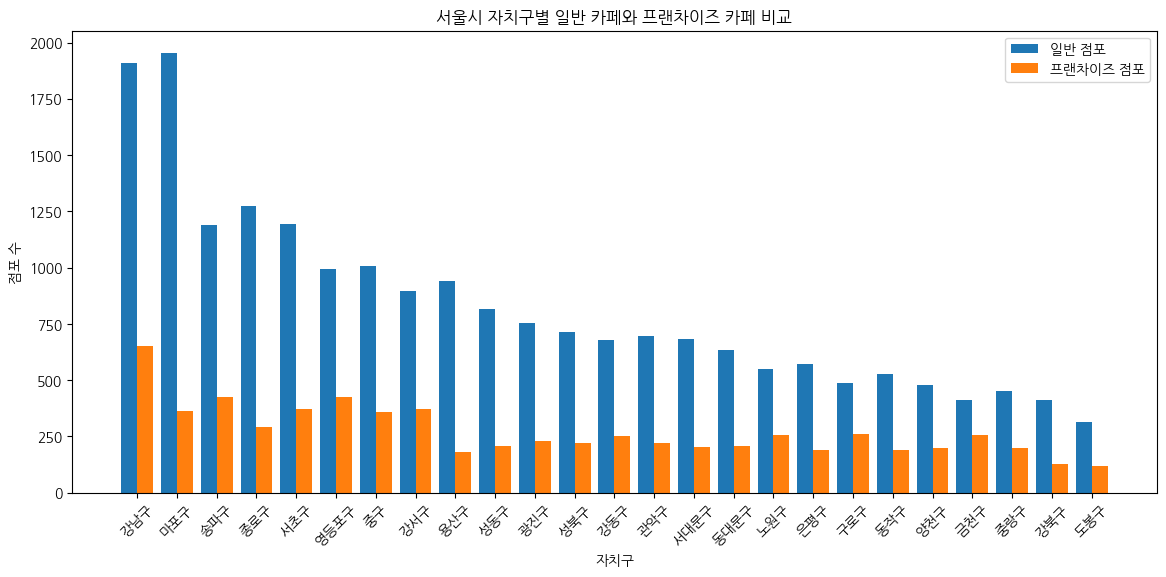

In [27]:
import numpy as np

x = np.arange(len(compare_df))
width = 0.4

plt.figure(figsize=(14, 6))

plt.bar(
    x - width/2,
    compare_df["일반_점포_수"],
    width,
    label="일반 점포"
)

plt.bar(
    x + width/2,
    compare_df["프랜차이즈_점포_수"],
    width,
    label="프랜차이즈 점포"
)

plt.title("서울시 자치구별 일반 카페와 프랜차이즈 카페 비교")
plt.xlabel("자치구")
plt.ylabel("점포 수")

plt.xticks(
    x,
    compare_df["자치구_코드_명"],
    rotation=45
)

plt.legend()
plt.show()

## 그래프 분석 결과

### 1. 서울시 자치구별 카페 점포 수
2026년 1분기 기준으로 서울시 자치구별 카페 점포 수를 비교한 결과,
강남구가 2,561개로 가장 많았고, 마포구가 2,320개로 그다음으로 많았다.

반면 도봉구는 432개로 가장 적었고,
강북구와 중랑구도 상대적으로 카페 점포 수가 적었다.

이를 통해 서울 안에서도 자치구에 따라 카페 점포 수의 차이가 크다는 것을 확인할 수 있었다.

### 2. 일반 카페와 프랜차이즈 카페 비교
대부분의 자치구에서 프랜차이즈 카페보다 일반 카페의 수가 더 많았다.

강남구는 일반 카페와 프랜차이즈 카페 모두 많은 편이었으며,
마포구는 전체 카페 수는 매우 많지만 강남구와 비교하면 프랜차이즈보다 일반 카페의 비중이 더 큰 모습을 확인할 수 있었다.

따라서 카페 창업을 고려할 때는 단순히 전체 카페 수뿐 아니라
일반 점포와 프랜차이즈 점포의 분포도 함께 살펴볼 필요가 있다.

※ 이번 분석은 카페 점포 수를 이용한 기초적인 경쟁 현황 분석이며,
카페 수가 적은 지역이 반드시 창업하기 좋은 지역이라는 의미는 아니다.
실제 창업 가능성을 판단하려면 매출, 유동인구, 임대료 등의 추가 데이터도 함께 분석해야 한다.

## 데이터 출처

- 데이터명: 서울시 상권분석서비스(점포-자치구)
- 제공기관: 서울신용보증재단
- 출처: 서울 열린데이터광장
- 분석 기준: 2026년 1분기
- 사용 업종: 커피-음료
- 사용 항목: 자치구명, 전체 점포 수, 일반 점포 수, 프랜차이즈 점포 수, 개업률, 폐업률

In [28]:
print("원본 데이터 크기:", df.shape)
print("가공 후 데이터 크기:", latest_cafe_df.shape)

원본 데이터 크기: (52270, 12)
가공 후 데이터 크기: (25, 8)
